# Neural Networks

## Introduction

In this exercise you will implement the neural network of Fig. 5.4 in several
steps. In each step you will train the model on an image-segmentation pair that
is provided, and use it to segment an unseen scan. You will also be asked to
critically analyze the behavior of the model in different scenarios.

The data for this exercise consists of the files dataForNN inside clip0.mat,
dataForNN foreBorder clip0.mat and dataForNN foreBorder clip1.mat. In
each file you will find the images trainingImage and trainingSegmentation,
which you should use to train your models, and another image testImage that
you should automatically segment with the trained models. The pixels belonging to the foreground vs. background in the segmentations have values 1 and 0,
respectively.

For each of the tasks below, you should implement models with M = 6 basis functions $\phi_m(x)$, and optimize the model parameters $\theta$ on the training data using stochastic gradient descent (Eq. (4.8)). Reasonable settings for the optimization are $N' = 200$ and $ν' = 0.005$, and you should run the algorithm for a sufficiently large number of iterations, e.g., $5000$. It is good practice to plot the evolution of the cross-entropy (Eq. (4.7)) across iterations, as this will allow you to fine-tune $N'$ and $ν'$ if needed. Since you will draw $N'$ new samples in each iteration, the evolution of the cross-entropy will be noisy – however the overall trend should be that it decreases as the iterations progress (and stabilizes before the training is ended). It is also recommended to visualize the output of the classifier on the training and/or test image during training, as in Fig. 4.2(b).

### Instructions for your report
Your report should be structured as follows:
* **Introduction**: a short summary of what your report is about, perhaps with a recap of some of the equations you'll be using in your solution.
* **Task 1, ..., 5**: for each specific task listed below, your code (in code cells), your results (as figures) as well as explanations of what is computed and what is shown in the figures (in Markdown cells). 
* **Conclusion**: a short summary of your findings.

This introduction should **not** be part of your report.

### Input data and code hints
Import Python libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

<font size="5">Initialization</font>

In [2]:
M = 6
noOfSamples = 200
vm = 0.005
numIter = 5000

# Load data
clip0 = np.load('dataForNN_inside_clip0.npy', allow_pickle=True).tolist()

TI = clip0['trainingImage']
TS = clip0['trainingSegmentation']
TestI = clip0['testImage']
TestS = clip0['testSegmentation']

# Show image
plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingImage'], cmap='gray')
plt.title('Training Image')
plt.show()

plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingSegmentation'], cmap='gray')
plt.title('Training Segmentation')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'dataForNN_inside_clip0.npy'

## Task 1: Pixel-wise logistic regression classifier

For the data file ```dataForNN_inside_clip0.mat``` implement a pixel-wise logistic regression classifier $p(l \vert d, \theta)$, using fixed basis functions of the form

$$ \phi_m (d) = \cos[\pi(m-1)d] $$

You can use $\hat{w}_m = 0, \forall m$ for initializing the stochastic gradient descent algorithm.

Include in your report:
- a plot of the evolution of the cross-entropy across iterations
- the final segmentation of the test image
- the quantity $a$ and the obtained classifier (as in figure ...)
- visualization of where training samples are located (e.g. show $N^{\prime}$ samples of the last iteration of the stochastic gradient descent algorithm)

> ***Hints:***
> - getInputFeatures() provides images patches as input features based on ```numberOfNeighbors```
> - getSamples() collects sample data
> - showLocationOfSamples() plots the collected sample data
> - def plotSeg() overlays a segmentation on top of an image
>
> - for the sake of simplicity, you should compute the gradient $\nabla E_{N^{\prime}}(\theta)$ using the method of infinite differences. E.g. 
>       
>       gradient[n] = (newCost - cost[i]) / delta
>
>   computes the gradient for the $i^{th}$ iteration for the $n^{th}$ theta parameter 


The following functions are provided:

    getInputFeatures(), getSamples(), showLocationOfSamples(), plotSeg()

In [ ]:
def getInputFeatures(image, numberOfNeighbors, shift=1):
    numberOfFeatures = numberOfNeighbors + 1

    leftNeighborImage = np.zeros_like(image)
    leftNeighborImage[:, shift:] = image[:, :-shift]

    rightNeighborImage = np.zeros_like(image)
    rightNeighborImage[:, :-shift] = image[:, shift:]

    topNeighborImage = np.zeros_like(image)
    topNeighborImage[shift:, :] = image[:-shift, :]

    bottomNeighborImage = np.zeros_like(image)
    bottomNeighborImage[:-shift, :] = image[shift:, :]

    leftTopNeighborImage = np.zeros_like(image)
    leftTopNeighborImage[shift:, shift:] = image[:-shift, :-shift]

    rightTopNeighborImage = np.zeros_like(image)
    rightTopNeighborImage[shift:, :-shift] = image[:-shift, shift:]

    leftBottomNeighborImage = np.zeros_like(image)
    leftBottomNeighborImage[:-shift, shift:] = image[shift:, :-shift]

    rightBottomNeighborImage = np.zeros_like(image)
    rightBottomNeighborImage[:-shift, :-shift] = image[shift:, shift:]

    if numberOfNeighbors == 0:
        features = image.ravel()
    elif numberOfNeighbors == 1:
        features = np.column_stack((image.ravel(), bottomNeighborImage.ravel()))
    elif numberOfNeighbors == 4:
        features = np.column_stack((
            image.ravel(),
            leftNeighborImage.ravel(),
            rightNeighborImage.ravel(),
            topNeighborImage.ravel(),
            bottomNeighborImage.ravel()
        ))
    elif numberOfNeighbors == 8:
        features = np.column_stack((
            image.ravel(),
            leftTopNeighborImage.ravel(),
            topNeighborImage.ravel(),
            rightTopNeighborImage.ravel(),
            leftNeighborImage.ravel(),
            rightNeighborImage.ravel(),
            leftBottomNeighborImage.ravel(),
            bottomNeighborImage.ravel(),
            rightBottomNeighborImage.ravel()
        ))
    else:
        raise NotImplementedError("Number of neighbors not implemented yet")

    featureImage = features.reshape((image.shape[0], image.shape[1], numberOfFeatures))
    return featureImage

def getSamples(featureImage, segmentation, numberOfSamples, mask=None):
    if mask is None:
        mask = np.ones(segmentation.shape)

    numberOfFeatures = featureImage.shape[2]
    numberOfPixels = featureImage.shape[0] * featureImage.shape[1]

    numberOfSamplesPerClass = int(np.ceil(numberOfSamples / 2))
    x = np.zeros((numberOfSamplesPerClass, numberOfFeatures, 2))
    t = np.zeros((numberOfSamplesPerClass, 2))
    rowAndColNumbers = np.zeros((numberOfSamplesPerClass, 2, 2))

    oneHotEncoding = np.zeros((segmentation.shape[0], segmentation.shape[1], 2))
    oneHotEncoding[:, :, 0] = segmentation
    oneHotEncoding[:, :, 1] = 1 - segmentation

    rows, cols = np.meshgrid(np.arange(1, featureImage.shape[0] + 1),
                             np.arange(1, featureImage.shape[1] + 1))

    for k in range(2):
        indices = np.where(oneHotEncoding[:, :, k] * mask)
        sampleIndices = np.random.choice(len(indices[0]), numberOfSamplesPerClass, replace=False)
        indices = (indices[0][sampleIndices], indices[1][sampleIndices])

        x[:, :, k] = featureImage[indices[0], indices[1]]
        t[:, k] = segmentation[indices[0], indices[1]]
        rowAndColNumbers[:, :, k] = np.stack((indices[0], indices[1]), axis=1)

    x = np.concatenate((x[:, :, 0], x[:, :, 1]), axis=0)
    t = np.concatenate((t[:, 0], t[:, 1]), axis=0)
    rowAndColNumbers = np.concatenate((rowAndColNumbers[:, :, 0], rowAndColNumbers[:, :, 1]), axis=0)

    x = x[:numberOfSamples, :]
    t = t[:numberOfSamples]
    rowAndColNumbers = rowAndColNumbers[:numberOfSamples, :]

    return x, t, rowAndColNumbers

def showLocationOfSamples(image, rowAndColNumbers, t):
    colors = ['b', 'r']
    markers = ['o', 'x']

    plt.imshow(image, cmap='gray')
    T = np.zeros([rowAndColNumbers.shape[0], 2])
    T[:,0] = t
    T[:,1] = t-1
    for k in range(2):
        tmp = rowAndColNumbers[np.where(T[:, k]), :]
        marker = markers[k]
        color = colors[k]
        plt.scatter(tmp[:,:,1], tmp[:,:,0], marker=marker, color=color, linewidth=0.75)
    
    plt.show

def plotSeg(image, segmentation):
    tmp = np.zeros((segmentation.shape[0], segmentation.shape[1], 3))
    tmp[:, :, 0] = 1 - segmentation
    tmp[:, :, 2] = segmentation
    plt.imshow(image, cmap='gray')
    plt.imshow(tmp, alpha = 0.5)

(6, 1)


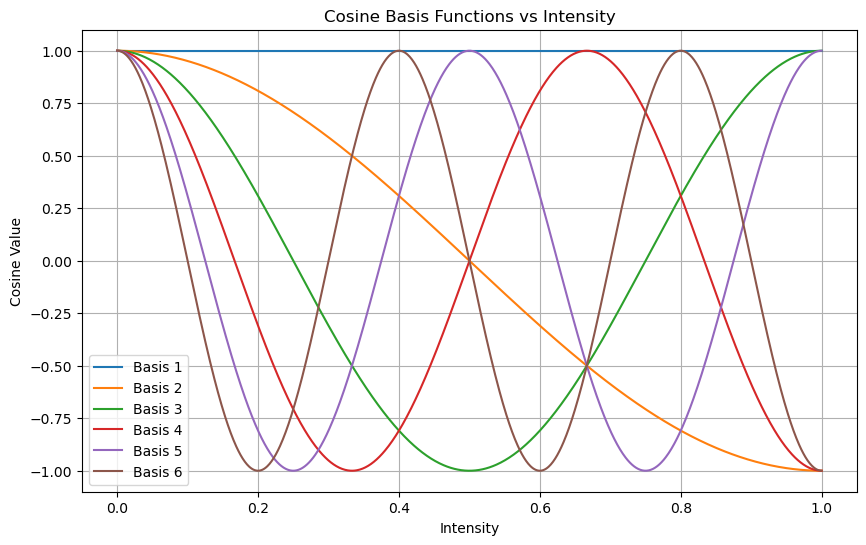

8008.007980032339
0.3475697908000147
[[0.11663568 0.11663568 0.11663568 ... 0.11663568 0.11663568 0.11663568]]
[[ 1.62434536 -0.61175641 -0.52817175 -1.07296862  0.86540763 -2.3015387 ]]


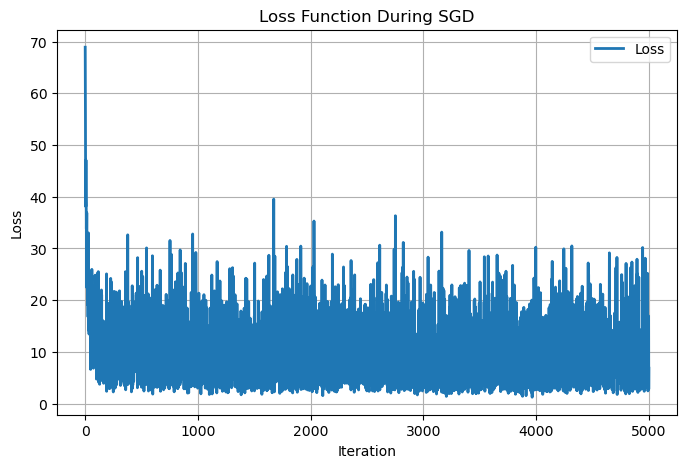

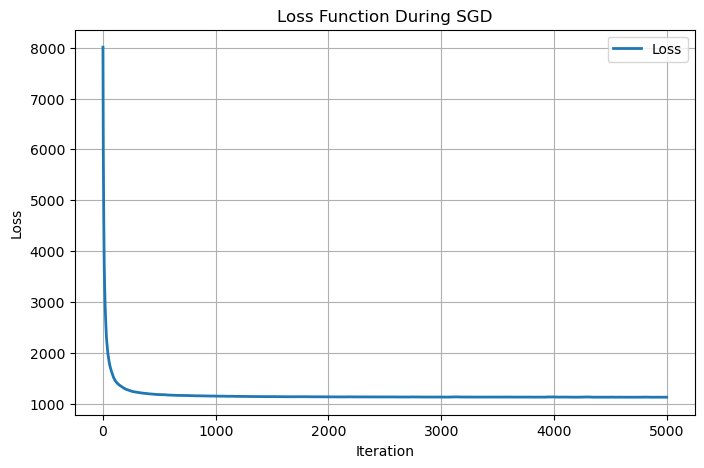

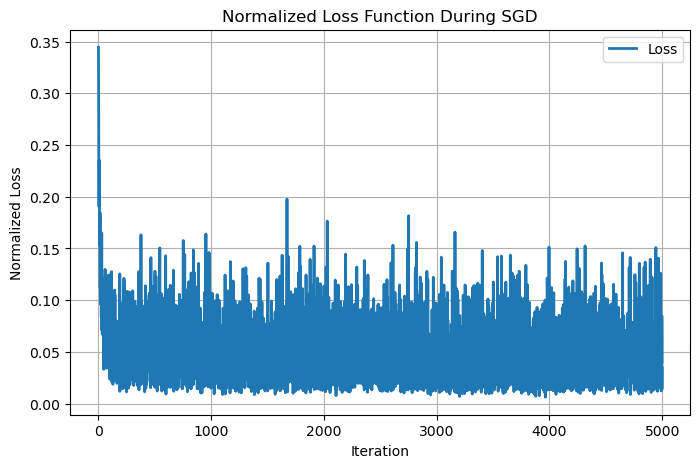

(5000, 6)
(5000, 6)


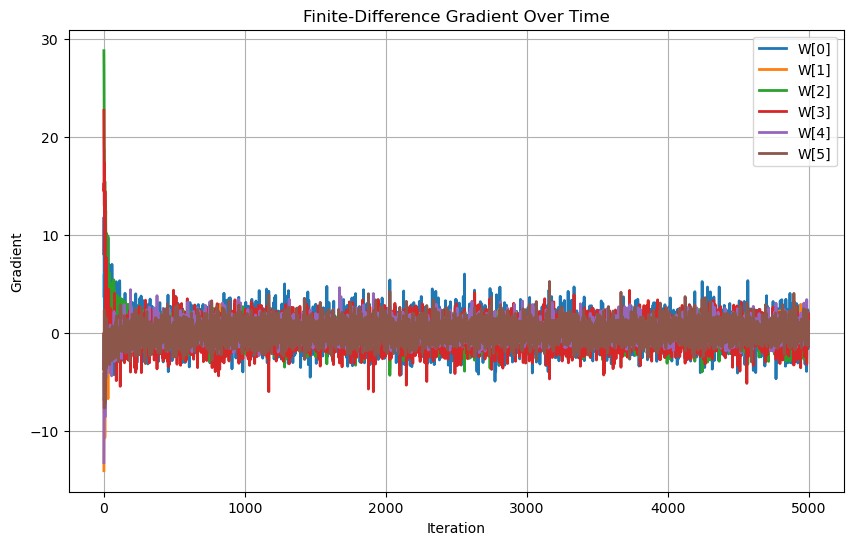

(5001, 1, 6)
(5001, 6)


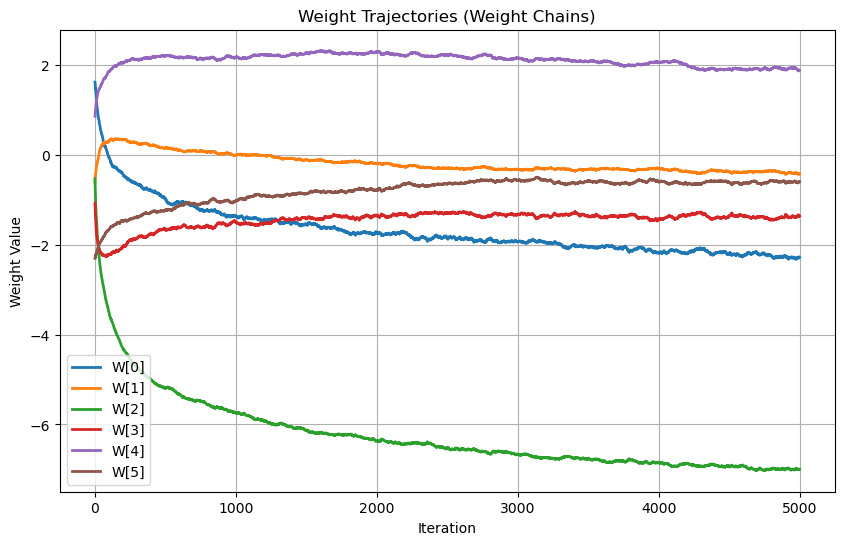

[-2.28235478 -0.41717741 -6.99875724 -1.36190919  1.88767811 -0.59295529]


In [ ]:
#First we make a function that can make the basis funcitons for a given image.
def MakeConsineBasis(M, Image):
    dn = Image.ravel()
    ConsineBasis = [np.cos(np.pi*(m-1)*dn) for m in np.arange(M)+1]
    return np.array(ConsineBasis)

TI1 = np.linspace(0,1,1000)
ConsineBasisF1 = MakeConsineBasis(6, TI1)
#And try and plot them for now:
print(MakeConsineBasis(6, np.ones(1)).shape)

# Plot each basis function against intensity
plt.figure(figsize=(10,6))
for i, basis in enumerate(ConsineBasisF1):
    plt.plot(TI1, basis, label=f'Basis {i+1}')   # <-- use TI1 on x-axis
plt.title("Cosine Basis Functions vs Intensity")
plt.xlabel("Intensity")
plt.ylabel("Cosine Value")
plt.legend()
plt.grid(True)
plt.show()

#Make prediciton:
LogSig = lambda x: 1/(1+np.exp(-x))
def MakePrediction(Weights, x, M): #Equation 4.2
    #Make sure that shape of weights is 1xN.
    Prediction = LogSig(Weights@MakeConsineBasis(M, x))
    return Prediction

#Now we need to implement the loss function/cross entropy.
#We could probably normalize based on the length of the arrays that we input. That would make it easier to compare losses.
def LossFunc(Weights, x, M, TrueLabels):
    Predictions = MakePrediction(Weights, x, M)
    Tn = TrueLabels.ravel()
    #From the book
    Loss = -np.sum(Tn*np.log(Predictions)+(1-Tn)*np.log(1-Predictions)) 
    #Normalized based on length (nevermind, that is not good, the losses become too small)
    #Loss = -np.mean(Tn*np.log(Predictions)+(1-Tn)*np.log(1-Predictions)) 
    return Loss

#And we need a function for calculating gradients, using fininte differences.
def ComputeFiniteGrad(Weights, x, M, TrueLabels, delta):
    #Allocate space and alter variables.
    base_loss = LossFunc(Weights, x, M, TrueLabels)
    LenW = len(np.squeeze(Weights))
    Weights = np.squeeze(Weights)
    grad = np.zeros_like(Weights)
    #for each weight, we perturbe it a little bit, and calculate the derivative for that weight.
    for j in range(LenW):
        W_perturbed = Weights.copy()
        W_perturbed[j] += delta
        loss_new = LossFunc(W_perturbed, x, M, TrueLabels)
        grad[j] = (loss_new - base_loss) / delta

    return grad


np.random.seed(1)
InintWeights = np.random.normal(loc=0.0, scale=1.0, size=(1,6))
#InintWeights = np.zeros((1,6))
print(LossFunc(InintWeights, TI, 6, TS))
#Also, print where we normailize, so that we might compare later.
print(LossFunc(InintWeights, TI, 6, TS)/len(TI.flatten()))
print(MakePrediction(InintWeights, TI, 6))

Loss_all = []
N_iter = 5000
TI_flat = TI.flatten()
TS_flat = TS.flatten()
Loss = []
W = []
W.append(InintWeights)
print(W[0])
M = 6
NStar = 200
delta = 0.005
gradient = []
nu = 0.005


for iter in range(N_iter):
    #Get random samples.
    #First we make a random mask that is 200 long.
    Mask = np.random.choice(len(TI_flat), NStar, replace=False)
    #Extract data.
    DataIntensity = TI_flat[Mask]
    DataLabel = TS_flat[Mask]
    
    #Calculate the current loss.
    Loss.append(LossFunc(W[iter], DataIntensity, M, DataLabel))
    Loss_all.append(LossFunc(W[iter], TI_flat, M, TS_flat))
    #Make a small pertubation and calculate the new loss.
    #LossNew = LossFunc(W[iter]+delta, DataIntensity, M, DataLabel)
    #gradient.append((LossNew-Loss[iter])/delta)

    #Nevermind, that was wrong, we have to perturbe each weight and observe the change in gradient. I made a function above for that express purpose.
    GradIter = ComputeFiniteGrad(W[iter], DataIntensity, M, DataLabel, delta)
    gradient.append(GradIter)

    #Now we can get the new weights based on eq. 4.8
    W.append(W[iter]-nu*gradient[iter])

Loss = np.array(Loss)

# --------------------------
# Plot 1: Loss vs Iteration
# --------------------------
plt.figure(figsize=(8,5))
plt.plot(Loss, label="Loss", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Function During SGD")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------
# Plot 1: Loss vs Iteration
# --------------------------
plt.figure(figsize=(8,5))
plt.plot(np.array(Loss_all), label="Loss", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Function During SGD")
plt.grid(True)
plt.legend()
plt.show()


# --------------------------
# Plot 2: Normalized Loss vs Iteration
# --------------------------
plt.figure(figsize=(8,5))
plt.plot(Loss/NStar, label="Loss", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Normalized Loss")
plt.title("Normalized Loss Function During SGD")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------
# Plot 3: Gradient vs Iteration
# --------------------------
print(np.array(gradient).shape)
G_mat = np.array([g.ravel() for g in gradient])
G_mat = np.squeeze(G_mat)
print(np.array(G_mat).shape)

plt.figure(figsize=(10,6))
for j in range(G_mat.shape[1]):
    plt.plot(G_mat[:, j], label=f"W[{j}]", linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("Gradient")
plt.title("Finite-Difference Gradient Over Time")
plt.grid(True)
plt.legend()
plt.show()


# --------------------------
# Plot 4: Weight Chains (each weight component separately)
# --------------------------
# Convert dictionary W into a 2D array for plotting
print(np.array(W).shape)
W_mat = np.array([w.ravel() for w in W])
W_mat = np.squeeze(W_mat)
print(np.array(W_mat).shape)

plt.figure(figsize=(10,6))
for j in range(W_mat.shape[1]):
    plt.plot(W_mat[:, j], label=f"W[{j}]", linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("Weight Value")
plt.title("Weight Trajectories (Weight Chains)")
plt.legend()
plt.grid(True)
plt.show()

print(W_mat[-1,:])

## Task 2: Manipulate Intensities in Test Image

Create a new test image by replacing the intensities in the original test image using the rule
$$ d_{new} = d^{1.3}. $$

Use the classifier trained above to segment this new test image.

In your report, reflect on the result you obtain. Do the two test images look similar? What about their segmentations?

Final learned weights for d^1.3:
[-2.08786754  1.36577952 -5.56611898 -4.53072416  0.75815384 -0.57396589]
Final learned weights for original
[-2.29134069 -0.37507354 -7.02628172 -1.36219774  1.87845858 -0.65188321]


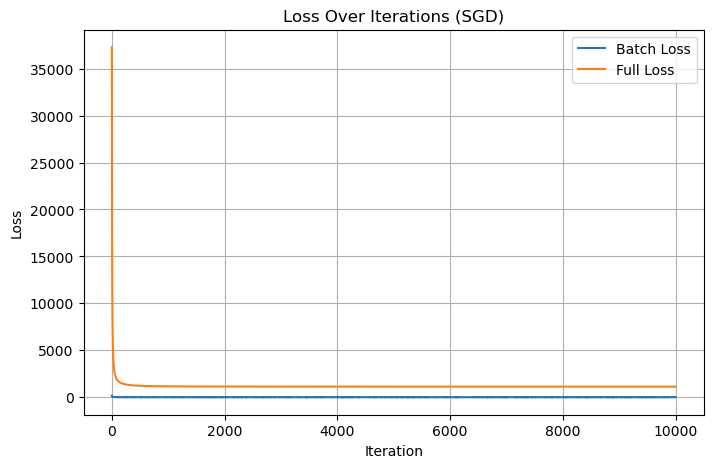

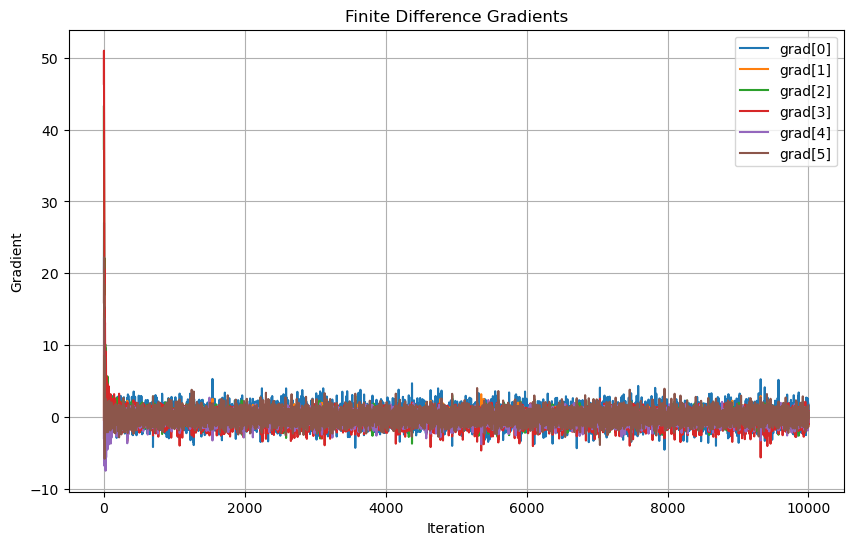

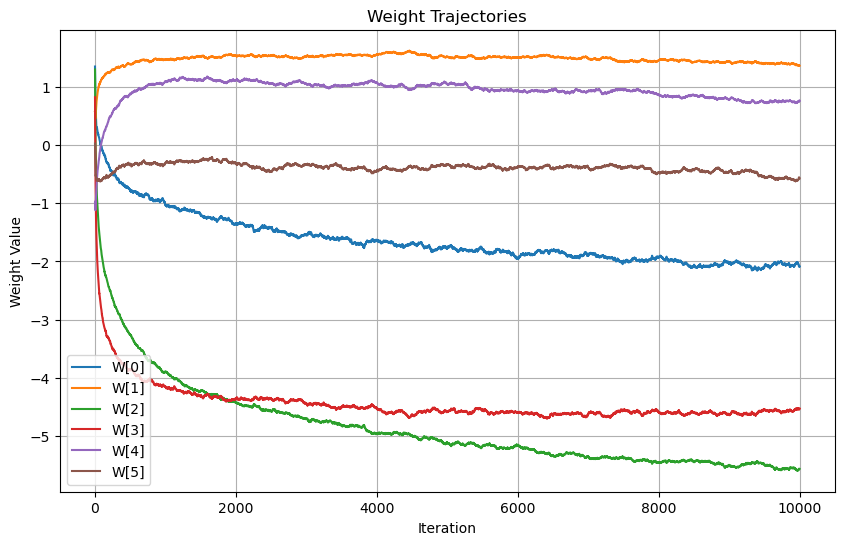

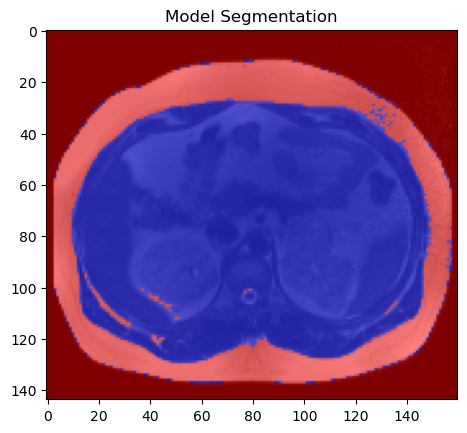

Now the original model


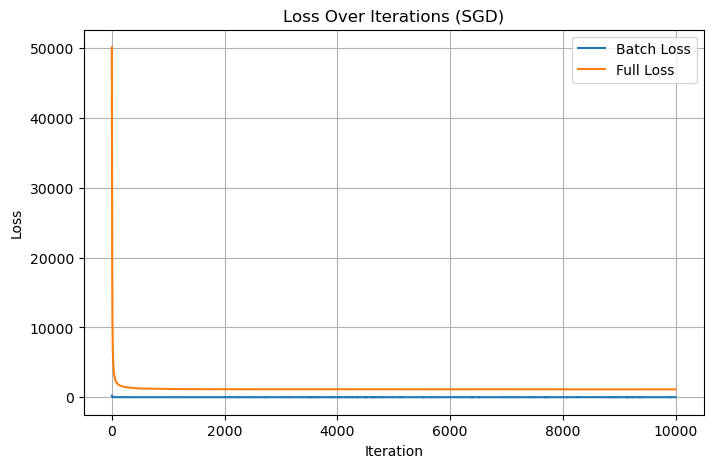

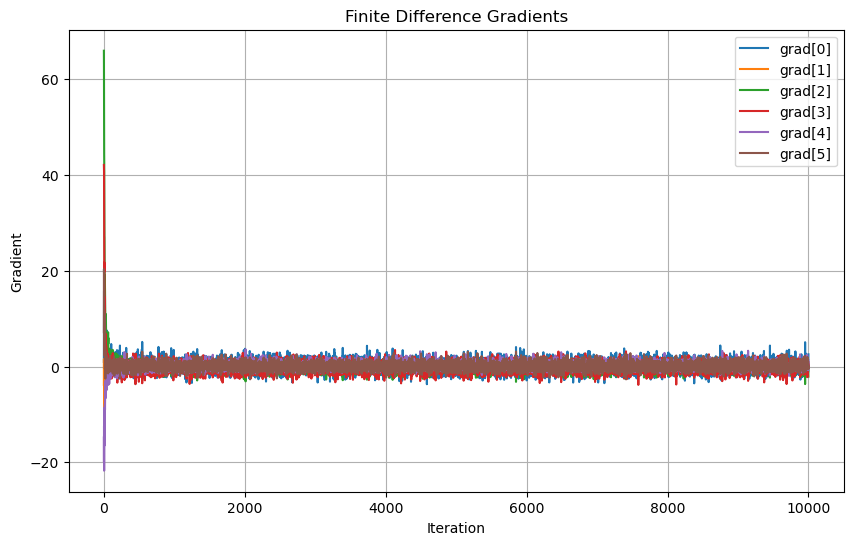

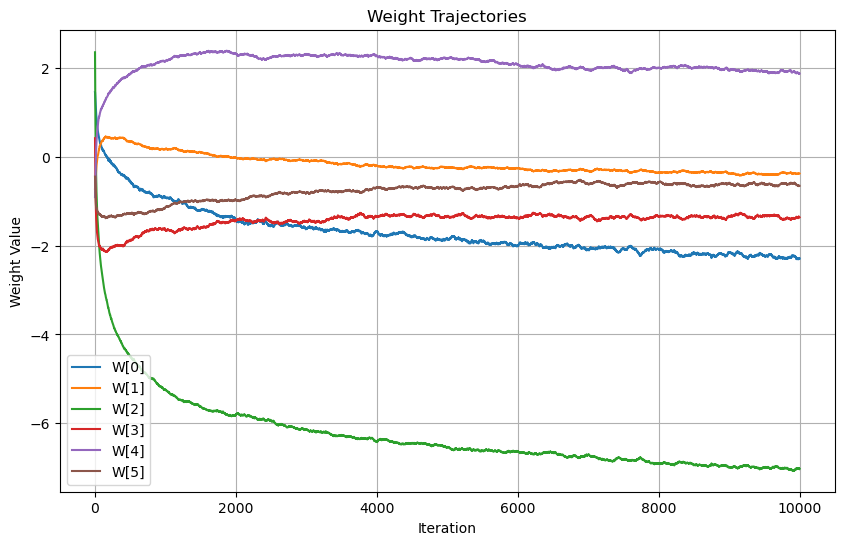

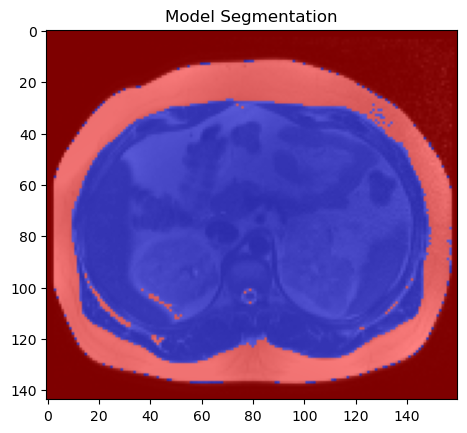

In [ ]:
# We can just make a function that does the simulation from task 1, and then alter the data before inputting it.
#We make chat make a class structure.
class CosineLogisticModel:
    def __init__(self, M, delta=0.01):
        """
        M     : number of cosine basis functions
        delta : finite difference step for gradient
        """
        self.M = M
        self.delta = delta
        self.weights = None
        self.loss_history_batch = []
        self.loss_history_full = []
        self.grad_history = []
        self.weight_chain = []

    # -------------------------------
    # Basis functions
    # -------------------------------
    def make_basis(self, x):
        dn = x.ravel()
        basis = [np.cos(np.pi * (m-1) * dn) for m in range(1, self.M+1)]
        return np.array(basis)          # shape (M, N)

    # -------------------------------
    # Prediction (sigma(W·phi(x)))
    # -------------------------------
    def predict(self, x):
        basis = self.make_basis(x)
        return 1 / (1 + np.exp(-(self.weights @ basis)))

    # -------------------------------
    # Cross-entropy loss
    # -------------------------------
    def loss(self, weights, x, t):
        basis = self.make_basis(x)
        preds = 1 / (1 + np.exp(-(weights @ basis)))
        eps = 1e-12
        preds = np.clip(preds, eps, 1 - eps)
        t = t.ravel()
        return -np.sum(t*np.log(preds) + (1-t)*np.log(1-preds))

    # -------------------------------
    # Finite difference gradient
    # -------------------------------
    def finite_grad(self, weights, x, t):
        base = self.loss(weights, x, t)
        grad = np.zeros_like(weights)
        for j in range(len(weights)):
            w_pert = weights.copy()
            w_pert[j] += self.delta
            new_loss = self.loss(w_pert, x, t)
            grad[j] = (new_loss - base) / self.delta
        return grad

    # -------------------------------
    # Training
    # -------------------------------
    def fit(self, x_full, t_full, lr=0.005, N_iter=3000, batch_size=200):
        """
        x_full      : full intensity array (flattened OK)
        t_full      : full labels (flattened OK)
        lr          : learning rate
        N_iter      : number of SGD iterations
        batch_size  : minibatch size
        """

        x_full = x_full.flatten()
        t_full = t_full.flatten()

        self.weights = np.random.normal(0, 1, self.M)
        self.loss_history_batch = []
        self.loss_history_full = []
        self.grad_history = []
        self.weight_chain = [self.weights.copy()]

        N = len(x_full)

        for it in range(N_iter):

            # 1. Sample minibatch
            idx = np.random.choice(N, batch_size, replace=False)
            x_batch = x_full[idx]
            t_batch = t_full[idx]

            # 2. Compute losses
            batch_loss = self.loss(self.weights, x_batch, t_batch)
            full_loss = self.loss(self.weights, x_full, t_full)

            self.loss_history_batch.append(batch_loss)
            self.loss_history_full.append(full_loss)

            # 3. Finite difference gradient
            grad = self.finite_grad(self.weights, x_batch, t_batch)
            self.grad_history.append(grad)

            # 4. Update
            self.weights = self.weights - lr * grad
            self.weight_chain.append(self.weights.copy())

        return self.weights
        # -------------------------------
    # Predict probability for an entire image
    # -------------------------------
    def predict_proba_image(self, image):
        """
        image : 2D grayscale image, values in [0,1]
        returns : 2D probability map
        """
        x = image.flatten()
        probs = self.predict(x)        # shape (N,)
        return probs.reshape(image.shape)

    # -------------------------------
    # Plot segmentation
    # -------------------------------
    def plot_segmentation(self, image):
        seg = self.segment_image(image)
        plotSeg(image, seg)
        plt.title("Model Segmentation")
        plt.show()

    def segment_image(self, image):
        x_flat = image.flatten()
        basis = self.make_basis(x_flat)       # (M, N)
        preds = 1 / (1 + np.exp(-(self.weights @ basis)))
        seg = (preds > 0.5).astype(int)
        return seg.reshape(image.shape)
    # -------------------------------
    # Plotting
    # -------------------------------

    def plot_losses(self):
        plt.figure(figsize=(8,5))
        plt.plot(self.loss_history_batch, label="Batch Loss")
        plt.plot(self.loss_history_full, label="Full Loss")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Loss Over Iterations (SGD)")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_gradients(self):
        G = np.array(self.grad_history)
        plt.figure(figsize=(10,6))
        for j in range(G.shape[1]):
            plt.plot(G[:, j], label=f"grad[{j}]")
        plt.xlabel("Iteration")
        plt.ylabel("Gradient")
        plt.title("Finite Difference Gradients")
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_weights(self):
        W = np.array(self.weight_chain)
        plt.figure(figsize=(10,6))
        for j in range(W.shape[1]):
            plt.plot(W[:, j], label=f"W[{j}]")
        plt.xlabel("Iteration")
        plt.ylabel("Weight Value")
        plt.title("Weight Trajectories")
        plt.grid(True)
        plt.legend()
        plt.show()

# Flatten data
pwr = 1.3
TI_flat2 = TI.flatten()**(pwr)
TS_flat2 = TS.flatten()

# Create model
modelOriginal = CosineLogisticModel(M = 6, delta = 0.005)
model = CosineLogisticModel(M=6, delta=0.005)
# Train
final_W = model.fit(
    x_full = TI_flat2,
    t_full = TS_flat2,
    lr = 0.005,
    N_iter = 10000,
    batch_size = 100
)
final_W_ori = modelOriginal.fit(
    x_full = TI_flat,
    t_full = TS_flat,
    lr = 0.005,
    N_iter = 10000,
    batch_size = 100
)

print("Final learned weights for d^1.3:")
print(final_W)

print("Final learned weights for original")
print(final_W_ori)

# Recreate plots
model.plot_losses()
model.plot_gradients()
model.plot_weights()
model.plot_segmentation(TI**(pwr))

print("Now the original model")

modelOriginal.plot_losses()
modelOriginal.plot_gradients()
modelOriginal.plot_weights()
modelOriginal.plot_segmentation(TI)

Final weights:
 [-0.65060795  0.12652584  0.11286147  1.28687396  0.24685255 -1.03233096
 -0.1257476  -0.99406111  1.36176556]


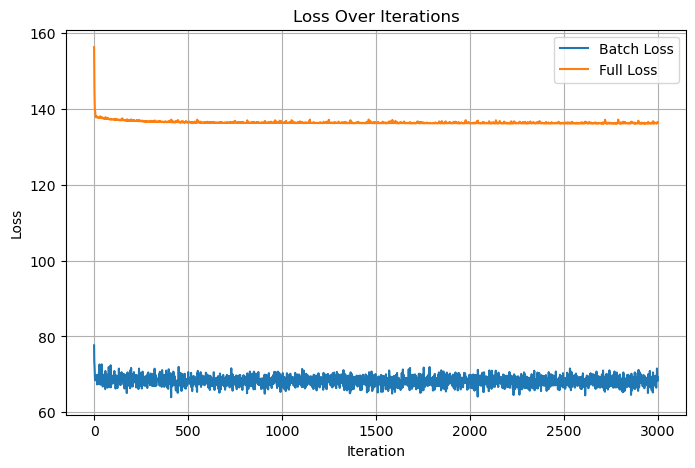

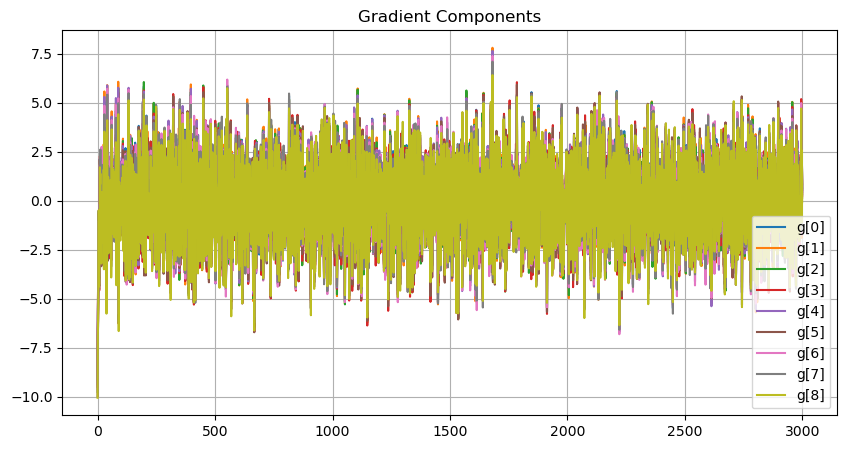

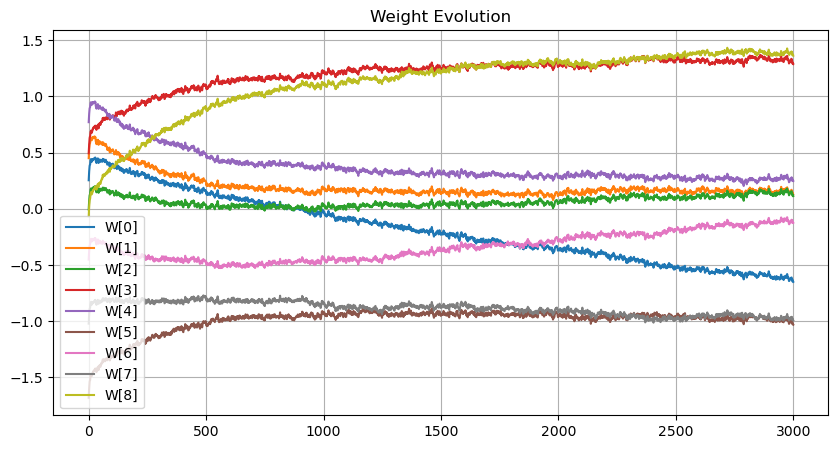

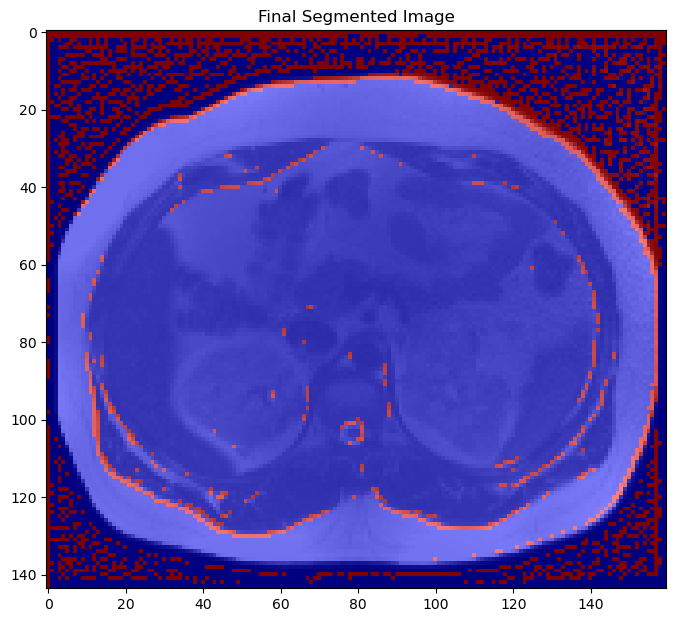

In [ ]:
#Now that this works we do:
class NeighborhoodLogisticModel:
    def __init__(self, num_features, delta=0.01):
        self.num_features = num_features
        self.delta = delta
        self.weights = None
        self.loss_history_batch = []
        self.loss_history_full = []
        self.grad_history = []
        self.weight_chain = []

    # ------------------------------------
    # Prediction σ(W·x)
    # ------------------------------------
    def predict(self, x):
        """
        x : shape (N_samples, num_features)
        """
        return 1 / (1 + np.exp(-(x @ self.weights)))

    # ------------------------------------
    # Cross-entropy loss
    # ------------------------------------
    def loss(self, weights, x, t):
        preds = 1 / (1 + np.exp(-(x @ weights)))
        eps = 1e-12
        preds = np.clip(preds, eps, 1 - eps)
        return -np.sum(t * np.log(preds) + (1 - t) * np.log(1 - preds))

    # ------------------------------------
    # Numerical gradient
    # ------------------------------------
    def finite_grad(self, weights, x, t):
        base = self.loss(weights, x, t)
        grad = np.zeros_like(weights)
        for j in range(len(weights)):
            w_pert = weights.copy()
            w_pert[j] += self.delta
            new_loss = self.loss(w_pert, x, t)
            grad[j] = (new_loss - base) / self.delta
        return grad

    # ------------------------------------
    # Training with SGD
    # ------------------------------------
    def fit(self, x_full, t_full, lr=0.005, N_iter=3000, batch_size=200):

        x_full = x_full.reshape(-1, self.num_features)
        t_full = t_full.flatten()

        N = len(t_full)

        self.weights = np.random.normal(0, 1, self.num_features)
        self.loss_history_batch = []
        self.loss_history_full = []
        self.grad_history = []
        self.weight_chain = [self.weights.copy()]

        for it in range(N_iter):

            # 1. minibatch
            idx = np.random.choice(N, batch_size, replace=False)
            xb = x_full[idx]
            tb = t_full[idx]

            # 2. losses
            Lb = self.loss(self.weights, xb, tb)
            Lf = self.loss(self.weights, x_full, t_full)

            self.loss_history_batch.append(Lb)
            self.loss_history_full.append(Lf)

            # 3. gradient
            g = self.finite_grad(self.weights, xb, tb)
            self.grad_history.append(g)

            # 4. update
            self.weights -= lr * g
            self.weight_chain.append(self.weights.copy())

        return self.weights

    # ------------------------------------
    # Segment entire image
    # ------------------------------------
    def segment_image(self, featureImage):
        """
        featureImage : shape (H, W, num_features)
        """
        H, W, _ = featureImage.shape
        X = featureImage.reshape(H*W, self.num_features)
        P = self.predict(X)
        seg = (P > 0.5).astype(int).reshape(H, W)
        return seg

    # ------------------------------------
    # Plotting utilities
    # ------------------------------------
    def plot_losses(self):
        plt.figure(figsize=(8,5))
        plt.plot(self.loss_history_batch, label="Batch Loss")
        plt.plot(self.loss_history_full, label="Full Loss")
        plt.xlabel("Iteration"); plt.ylabel("Loss")
        plt.title("Loss Over Iterations"); plt.grid(); plt.legend()
        plt.show()

    def plot_gradients(self):
        G = np.array(self.grad_history)
        plt.figure(figsize=(10,5))
        for j in range(G.shape[1]):
            plt.plot(G[:, j], label=f"g[{j}]")
        plt.title("Gradient Components")
        plt.grid(); plt.legend()
        plt.show()

    def plot_weights(self):
        W = np.array(self.weight_chain)
        plt.figure(figsize=(10,5))
        for j in range(W.shape[1]):
            plt.plot(W[:, j], label=f"W[{j}]")
        plt.title("Weight Evolution")
        plt.grid(); plt.legend()
        plt.show()


# 1. Create neighbor features
featureImage = getInputFeatures(TI, numberOfNeighbors=8, shift=1)
num_features = featureImage.shape[2]

# 2. Sample training pixels
x_train, t_train, rc = getSamples(featureImage, TS, numberOfSamples=200)

# 3. Create model
model = NeighborhoodLogisticModel(num_features=num_features, delta=0.01)

# 4. Train model
finalW = model.fit(x_train, t_train, lr=0.005, N_iter=3000, batch_size=100)

print("Final weights:\n", finalW)

# 5. Plot training curves
model.plot_losses()
model.plot_gradients()
model.plot_weights()

# Full segmentation using all pixels
seg_full = model.segment_image(featureImage)

plt.figure(figsize=(8,8))
plotSeg(TI, seg_full)
plt.title("Final Segmented Image")
plt.show()


## Task 3: Adaptive Basis Functions

Now replace the fixed cosine basis functions in your model with adaptive ones of the type Eq. (4.9), and train the classifier again. The extra parameters $\beta_{m,j}$ can be initialized randomly, distributed according to a zero-mean Gaussian distribution with unit variance. For the trained model, visualize again the obtained classifier and the resulting segmentation of the original test image. This time, also include a plot of the estimated basis functions $\phi_m(d)$.



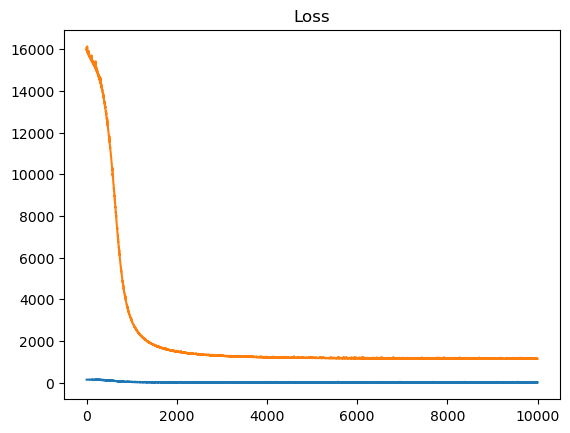

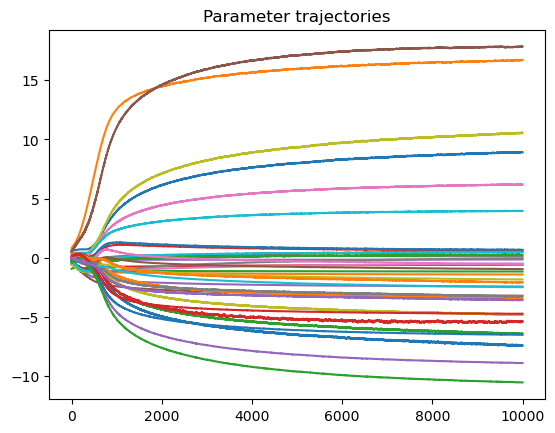

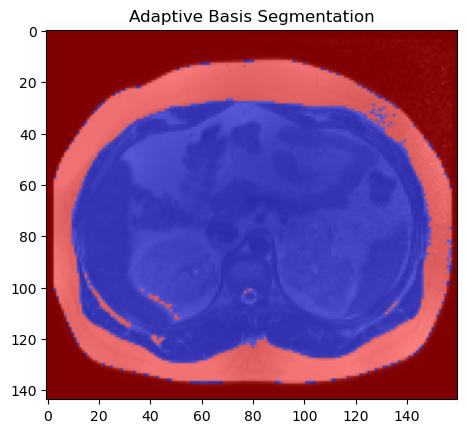

In [ ]:
# We alter the previous class structure.
#And make the basis according to 4.9
class AdaptiveBasisLogisticModel:
    def __init__(self, M, D=1, delta=0.01):
        """
        M     : number of adaptive basis functions
        D     : number of input features per pixel
        delta : finite difference step for gradient
        """
        self.M = M
        self.D = D
        self.delta = delta

        # Trainable parameters:
        # β: shape (M, D)      basis weights
        # β0: shape (M,)       basis biases
        # w: shape (M,)        final layer weights
        self.beta = None
        self.beta0 = None
        self.w = None

        # histories
        self.loss_history_batch = []
        self.loss_history_full = []
        self.weight_chain = []
        self.grad_history = []

    # --------------------------------------------
    # Build φ(x) for a set of samples x (shape: N × D)
    # --------------------------------------------
    def make_basis(self, x):
        """
        x : shape (N, D)
        returns φ : shape (N, M)
        """
        z = x @ self.beta.T + self.beta0  # (N, M)
        return 1 / (1 + np.exp(-z))       # sigmoid activation

    # --------------------------------------------
    # Predict sigmoid output for samples x
    # --------------------------------------------
    def predict(self, x):
        phi = self.make_basis(x)          # (N, M)
        return 1 / (1 + np.exp(-(phi @ self.w)))  # (N,)

    # --------------------------------------------
    # Cross-entropy loss
    # --------------------------------------------
    def loss(self, x, t):
        preds = self.predict(x)
        eps = 1e-12
        preds = np.clip(preds, eps, 1-eps)
        return -np.sum(t*np.log(preds) + (1-t)*np.log(1-preds))

    # --------------------------------------------
    # Flatten parameters into a single vector
    # --------------------------------------------
    def pack_params(self):
        return np.concatenate([
            self.beta.ravel(),
            self.beta0,
            self.w
        ])

    # ------------------------------
    # Unpack parameters from vector
    # ------------------------------
    def unpack_params(self, p):
        B = self.M * self.D
        b0 = self.M
        w = self.M

        self.beta = p[:B].reshape(self.M, self.D)
        self.beta0 = p[B:B+b0]
        self.w = p[B+b0:B+b0+w]

    # --------------------------------------------
    # Finite difference gradient wrt all params
    # --------------------------------------------
    def finite_grad(self, x, t):
        p = self.pack_params()
        base_loss = self.loss(x, t)

        grad = np.zeros_like(p)
        for i in range(len(p)):
            p2 = p.copy()
            p2[i] += self.delta
            self.unpack_params(p2)
            l2 = self.loss(x, t)
            grad[i] = (l2 - base_loss) / self.delta

        # restore original params
        self.unpack_params(p)
        return grad

    # --------------------------------------------
    # Training (same interface as before)
    # --------------------------------------------
    def fit(self, x_full, t_full, lr=0.005, N_iter=3000, batch_size=200):

        x_full = x_full.reshape(-1, self.D)
        t_full = t_full.flatten()

        # initialize parameters
        self.beta = np.random.normal(0, 0.5, (self.M, self.D))
        self.beta0 = np.zeros(self.M)
        self.w = np.random.normal(0, 0.5, self.M)

        p = self.pack_params()
        self.weight_chain = [p.copy()]

        N = len(x_full)

        for it in range(N_iter):
            idx = np.random.choice(N, batch_size, replace=False)
            x_b = x_full[idx]
            t_b = t_full[idx]

            batch_loss = self.loss(x_b, t_b)
            full_loss  = self.loss(x_full, t_full)

            self.loss_history_batch.append(batch_loss)
            self.loss_history_full.append(full_loss)

            grad = self.finite_grad(x_b, t_b)
            self.grad_history.append(grad.copy())

            p = p - lr * grad
            self.unpack_params(p)
            self.weight_chain.append(p.copy())

        return self.w

    # --------------------------------------------
    # Predict full image
    # --------------------------------------------
    def predict_proba_image(self, image):
        x = image.flatten().reshape(-1, self.D)
        probs = self.predict(x)
        return probs.reshape(image.shape)

    def segment_image(self, image):
        return (self.predict_proba_image(image) > 0.5).astype(int)

    def plot_segmentation(self, image):
        seg = self.segment_image(image)
        plotSeg(image, seg)
        plt.title("Adaptive Basis Segmentation")
        plt.show()

    # --------------------------------------------
    # Plots
    # --------------------------------------------
    def plot_losses(self):
        plt.figure()
        plt.plot(self.loss_history_batch)
        plt.plot(self.loss_history_full)
        plt.title("Loss")
        plt.show()

    def plot_weights(self):
        W = np.array(self.weight_chain)
        plt.figure()
        plt.plot(W)
        plt.title("Parameter trajectories")
        plt.show()


TI_flat = TI.flatten().reshape(-1,1)  # D=1
TS_flat = TS.flatten()

model = AdaptiveBasisLogisticModel(M=6, D=1, delta=0.01)

final_w = model.fit(
    x_full = TI_flat,
    t_full = TS_flat,
    lr = 0.005,
    N_iter = 10000,
    batch_size = 200
)

model.plot_losses()
model.plot_weights()
model.plot_segmentation(TI)


## Task 4: Use Neighbour Pixel as second Input Feature

Using the data in the file ```dataForNN_foreBorder_clip1.mat```, re-train and re-apply your classifier, but this time not just based on the intensity in the pixel being classified, but also on that of the pixel in the next row (i.e., the input x is now a vector of dimension $p = 2$). In addition to showing the classifier output on the test image, also include in your report a visualization of the learned basis functions $\phi_m(d)$ in the 2D input space, along with the learned classifier (again in the 2D input space). For the latter, please include a visualization of where the training samples $\{x_i , y_i \}$ are located (cf. the first task).

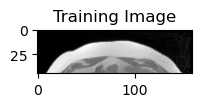

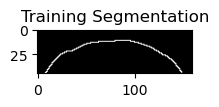

(7200, 2)


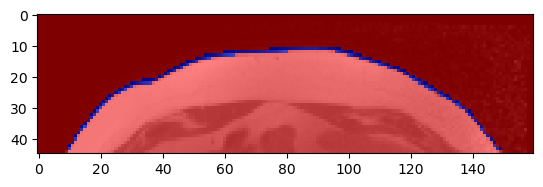

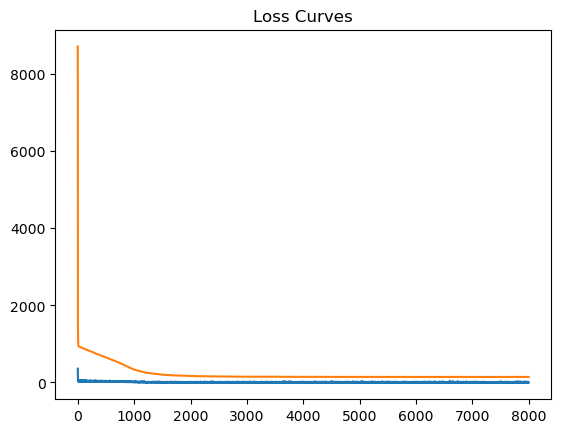

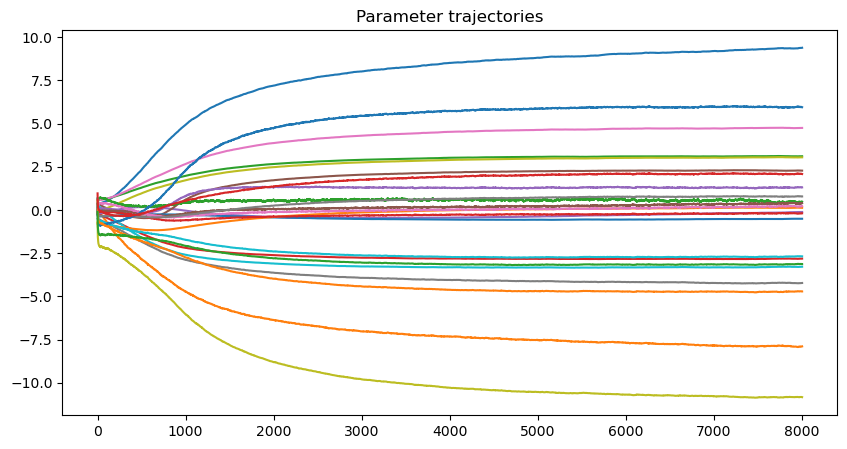

In [ ]:
#First we need to load the new data:
# Load data
clip0 = np.load('dataForNN_foreBorder_clip1.npy', allow_pickle=True).tolist()

TI = clip0['trainingImage']
TS = clip0['trainingSegmentation']
TestI = clip0['testImage']
TestS = clip0['testSegmentation']

# Show image
plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingImage'], cmap='gray')
plt.title('Training Image')
plt.show()

plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingSegmentation'], cmap='gray')
plt.title('Training Segmentation')
plt.show()

class AdaptiveBasisLogisticModel:
    def __init__(self, M, D=1, delta=0.01):
        """
        M : number of adaptive basis functions
        D : number of input features
        delta : finite diff step
        """
        self.M = M
        self.D = D
        self.delta = delta

        # Trainable parameters
        self.beta = None     # (M, D)
        self.beta0 = None    # (M,)
        self.w = None        # (M,)

        # histories
        self.loss_history_batch = []
        self.loss_history_full = []
        self.weight_chain = []
        self.grad_history = []

    # --------------------------------------------
    # Build φ(x) for samples x:  x has shape (N, D)
    # φ(x) has shape (N, M)
    # --------------------------------------------
    def make_basis(self, x):
        z = x @ self.beta.T + self.beta0      # (N, M)
        return 1 / (1 + np.exp(-z))           # sigmoid

    # --------------------------------------------
    def predict(self, x):
        phi = self.make_basis(x)
        return 1 / (1 + np.exp(-(phi @ self.w)))

    # --------------------------------------------
    def loss(self, x, t):
        preds = self.predict(x)
        eps = 1e-12
        preds = np.clip(preds, eps, 1 - eps)
        return -np.sum(t*np.log(preds) + (1-t)*np.log(1-preds))

    # --------------------------------------------
    # pack all params into a vector
    # --------------------------------------------
    def pack_params(self):
        return np.concatenate([
            self.beta.ravel(),
            self.beta0,
            self.w
        ])

    def unpack_params(self, p):
        B = self.M * self.D
        b0 = self.M
        w = self.M

        self.beta = p[:B].reshape(self.M, self.D)
        self.beta0 = p[B:B+b0]
        self.w = p[B+b0:B+b0+w]

    # --------------------------------------------
    # expensive but simple finite diff gradient
    # --------------------------------------------
    def finite_grad(self, x, t):
        p = self.pack_params()
        base_loss = self.loss(x, t)

        grad = np.zeros_like(p)
        for i in range(len(p)):
            p2 = p.copy()
            p2[i] += self.delta
            self.unpack_params(p2)
            L2 = self.loss(x, t)
            grad[i] = (L2 - base_loss) / self.delta

        self.unpack_params(p)
        return grad

    # --------------------------------------------
    # Training
    # --------------------------------------------
    def fit(self, x_full, t_full, lr=0.005, N_iter=3000, batch_size=200):

        x_full = x_full.reshape(-1, self.D)
        t_full = t_full.flatten()

        # initialize parameters
        self.beta = np.random.normal(0, 0.5, (self.M, self.D))
        self.beta0 = np.zeros(self.M)
        self.w = np.random.normal(0, 0.5, self.M)

        p = self.pack_params()
        self.weight_chain = [p.copy()]

        N = len(x_full)

        for it in range(N_iter):
            idx = np.random.choice(N, batch_size, replace=False)
            xb = x_full[idx]
            tb = t_full[idx]

            batch_loss = self.loss(xb, tb)
            full_loss = self.loss(x_full, t_full)

            self.loss_history_batch.append(batch_loss)
            self.loss_history_full.append(full_loss)

            grad = self.finite_grad(xb, tb)

            p = p - lr * grad
            self.unpack_params(p)
            self.weight_chain.append(p.copy())

        return self.w

    # --------------------------------------------
    # Full-image prediction
    # --------------------------------------------
    def predict_proba_image(self, feature_img):
        """
        feature_img : (H, W, D)
        """
        x = feature_img.reshape(-1, self.D)
        probs = self.predict(x)
        H, W, _ = feature_img.shape
        return probs.reshape(H, W)

    def segment_image(self, feature_img):
        return (self.predict_proba_image(feature_img) > 0.5).astype(int)

    def plot_segmentation(self, image, feature_img):
        seg = self.segment_image(feature_img)
        plotSeg(image, seg)
        plt.title("Adaptive Basis Segmentation (D inputs)")
        plt.show()

    # --------------------------------------------
    # Plots
    # --------------------------------------------
    def plot_losses(self):
        plt.figure()
        plt.plot(self.loss_history_batch)
        plt.plot(self.loss_history_full)
        plt.title("Loss Curves")
        plt.show()

    def plot_weights(self):
        W = np.array(self.weight_chain)
        plt.figure(figsize=(10,5))
        plt.plot(W)
        plt.title("Parameter trajectories")
        plt.show()


feat_img = getInputFeatures(TI, numberOfNeighbors=1)   # (H, W, 2)
H, W, D = feat_img.shape

x_train = feat_img.reshape(-1, D)
print(x_train.shape)
t_train = TS.flatten()
model = AdaptiveBasisLogisticModel(M=6, D=2, delta=0.01)

model.fit(
    x_full=x_train,
    t_full=t_train,
    lr=0.005,
    N_iter=8000,
    batch_size=300
)
seg = model.segment_image(feat_img)
plotSeg(TI, seg)
model.plot_losses()
model.plot_weights()


## Task 5: Use 8 Neighbours as Input Features

Using the data in the file ```dataForNN_foreBorder_clip0.mat```, re-train and re-apply the same classifier, but now using 3 × 3 patches as input, i.e., the input $x$ is now a vector of dimension $p = 9$. In your report you should include the classifier output on the test image, as well as the feature maps and the corresponding model weights $\{ \beta_{m,j} \}^{p}_{j=1}$ as visualized in Fig. 4.5(d) and Fig. 4.5(e), respectively.

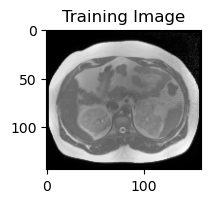

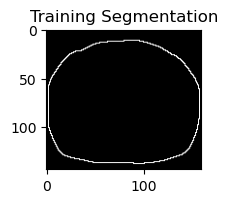

(23040, 9)


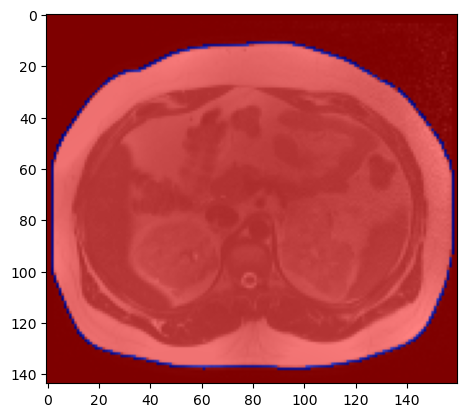

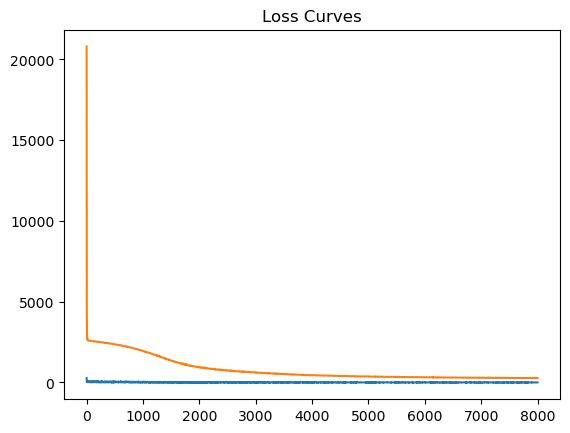

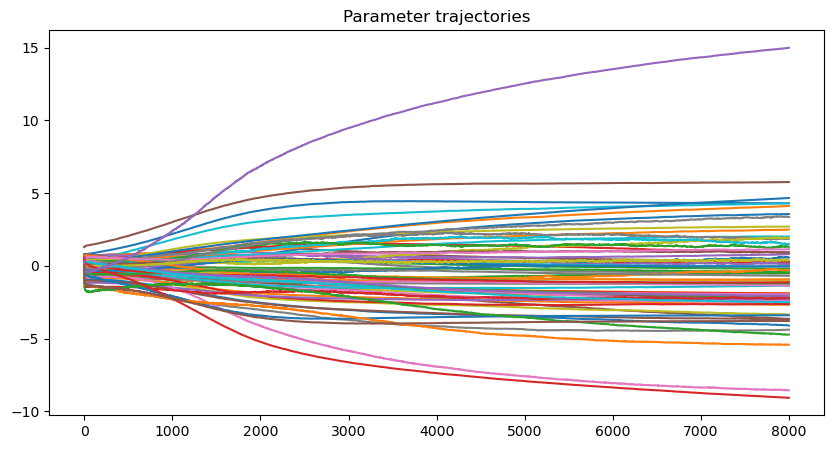

In [ ]:

# Load data
clip0 = np.load('dataForNN_foreBorder_clip0.npy', allow_pickle=True).tolist()

TI_T5 = clip0['trainingImage']
TS_T5 = clip0['trainingSegmentation']
TestI_T5 = clip0['testImage']
TestS_T5 = clip0['testSegmentation']

# Show image
plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingImage'], cmap='gray')
plt.title('Training Image')
plt.show()

plt.figure(figsize=(2,2))
plt.imshow(clip0['trainingSegmentation'], cmap='gray')
plt.title('Training Segmentation')
plt.show()


#We can use the class from before, but alter the way that we pack the features.
feat_img = getInputFeatures(TI_T5, numberOfNeighbors=8)   # (H, W, 2)
H, W, D = feat_img.shape

x_train = feat_img.reshape(-1, D)
print(x_train.shape)
t_train = TS_T5.flatten()
model = AdaptiveBasisLogisticModel(M=6, D=9, delta=0.01)

model.fit(
    x_full=x_train,
    t_full=t_train,
    lr=0.005,
    N_iter=8000,
    batch_size=300
)
seg = model.segment_image(feat_img)
plotSeg(TI_T5, seg)
model.plot_losses()
model.plot_weights()

## Task 6: (for the enthusiastic student)

In order to provide a more challenging task to the neural network, do task 4 again but this time using the data in the file ```dataForNN_foreBorder_clip0.mat```. Concentrate on the visualization of the learned basis functions and especially that of the classifier with respect to the training samples. Can you explain why this scenario is more challenging than the one of task 4? You can also try to add another hidden layer in the network – what do the basis functions look like now?